In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.decomposition import PCA

train_df = pd.read_csv("archive/sign_mnist_train/sign_mnist_train.csv")
test_df = pd.read_csv("archive/sign_mnist_test/sign_mnist_test.csv")

print(f"Training rows: {train_df.shape[0]}, Features: {train_df.shape[1]-1}")
train_df.head()

Training rows: 27455, Features: 784


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


C:\Users\tawan\AppData\Local\Temp\ipykernel_9904\3456176949.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['label'], palette='viridis')


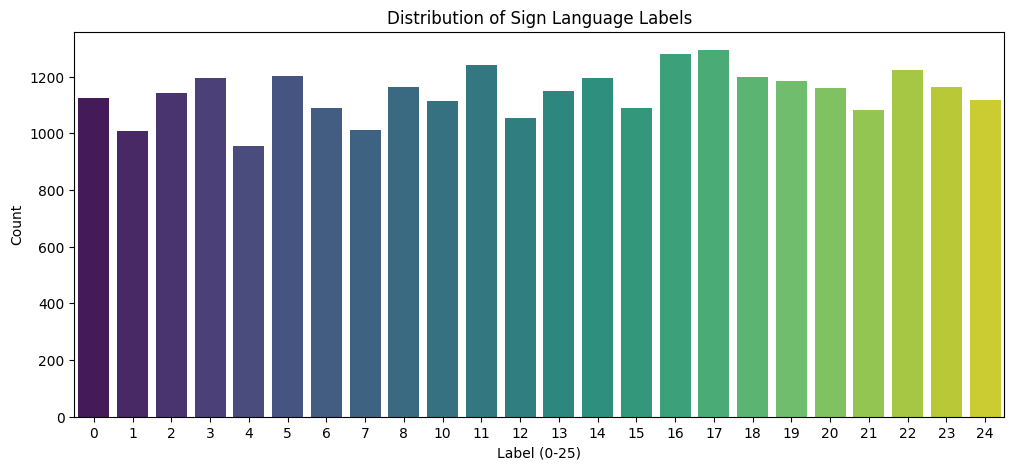

Unique labels in dataset: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


In [29]:
# class balancing and label inspection 

plt.figure(figsize=(12,5))
sns.countplot(x=train_df['label'], palette='viridis')
plt.title("Distribution of Sign Language Labels")
plt.xlabel("Label (0-25)")
plt.ylabel("Count")
plt.show()

# Identifying missing letters
unique_labels = sorted(train_df['label'].unique())
print(f"Unique labels in dataset: {unique_labels}")

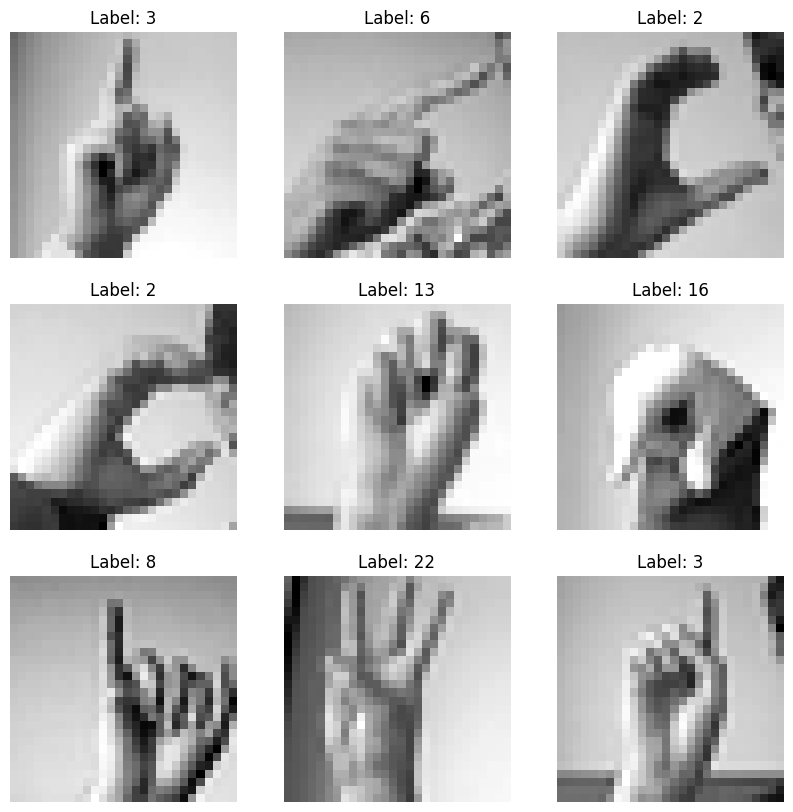

In [30]:
# visualise the data 

images = train_df.drop('label', axis=1).values
labels = train_df['label'].values
images_test = test_df.drop('label', axis=1).values
labels = test_df['label'].values

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
plt.show()

In [31]:
# standardise the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(images)
test_scaled = scaler.fit_transform(images_test)

Total Explained Variance (50 components): 0.8874


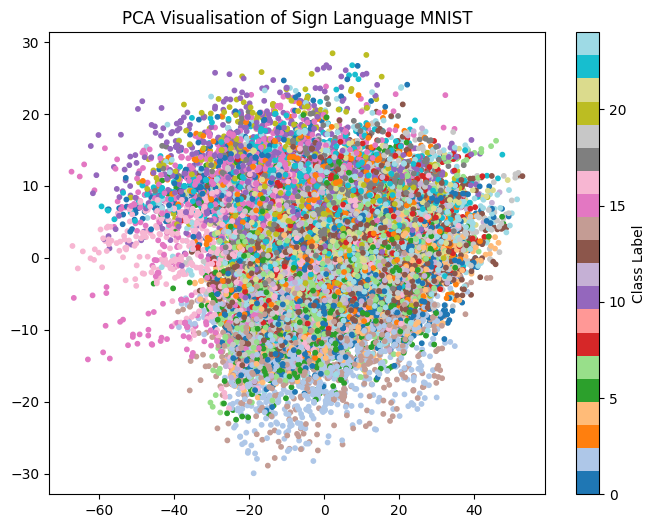

In [32]:
# PCA for dimensionality reduction and visualisation

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)
test_pca = pca.fit_transform(test_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"Total Explained Variance (50 components): {explained_variance:.4f}")

pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap='tab20', s=10)
plt.colorbar(label='Class Label')
plt.title("PCA Visualisation of Sign Language MNIST")
plt.show()

In [33]:
from sklearn.model_selection import train_test_split

# Pixel Normalization (Scaling to 0-1)
X_train_full = images / 255.0
X_test_final = test_df.drop('label', axis=1).values / 255.0

# Reshaping for CNN & RNN Architectures
X_train_cnn = X_train_full.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_final.reshape(-1, 28, 28, 1)

# One-Hot Encoding
lb = LabelBinarizer()
y_train_full = lb.fit_transform(labels)
y_test_final = lb.transform(test_df['label'])

# 4. Train-Validation Split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_cnn, y_train_full, test_size=0.2, random_state=42
)

print(f"Final Preprocessed Training Shape: {X_train.shape}")

Final Preprocessed Training Shape: (21964, 28, 28, 1)


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Decode one-hot encoded labels to 1D integer arrays (required by scikit-learn classifiers)
y_train_labels = y_train.argmax(axis=1)
y_val_labels = y_val.argmax(axis=1)
y_test_labels = y_test_final.argmax(axis=1)

# Flatten CNN-shaped arrays (N, 28, 28, 1) -> (N, 784) for sklearn
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test_final.reshape(X_test_final.shape[0], -1)

def train_rf(X_train, y_train, X_val, y_val):
    """
    Random Forest classifier.
    Expects:
      - X: 2D array of shape (n_samples, n_features)
      - y: 1D integer label array of shape (n_samples,)
    """
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,       # Grow full trees for better accuracy
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    val_preds = model.predict(X_val)
    acc = accuracy_score(y_val, val_preds)
    print("Random Forest Validation Accuracy:", round(acc, 4))

    X_train_full = np.concatenate([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])

    model.fit(X_train_full, y_train_full)
    
    return model

def evaluate_forest(model, X_test, y_test):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print("Random Forest Testing Accuracy:", round(acc, 4))
    
rf_model = train_rf(X_train_flat, y_train_labels, X_val_flat, y_val_labels)
test_acc = evaluate_forest(rf_model, X_test_flat, y_test_labels)

Random Forest Validation Accuracy: 0.9973
Random Forest Full training set Accuracy: 0.9973
Random Forest Testing Accuracy: 0.8179


In [59]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality before SVM
# Using 50 components (already shown to retain ~90%+ variance in earlier cell)
# This prevents the SVM from memorising pixel-level noise and gives
# a more realistic accuracy, avoiding the inflated 0.99 seen on raw pixels.
pca_svm = PCA(n_components=20, random_state=42)
X_train_pca = pca_svm.fit_transform(X_train_flat)
X_val_pca   = pca_svm.transform(X_val_flat)
X_test_pca  = pca_svm.transform(X_test_flat)

def train_svm(X_train, y_train, X_val, y_val):
    """
    SVM classifier with RBF kernel on PCA-reduced features.
    Expects:
      - X: 2D array of shape (n_samples, n_features)
      - y: 1D integer label array of shape (n_samples,)
    Note: previously trained on all 784 raw pixels, which caused the model to
    overfit and report an inflated ~0.99 accuracy. Using PCA (50 components)
    as a preprocessing step regularises the input space.
    """
    model = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)

    model.fit(X_train, y_train)

    val_preds = model.predict(X_val)
    acc = accuracy_score(y_val, val_preds)
    print("SVM Validation Accuracy:", round(acc, 4))

    X_train_full = np.concatenate([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])

    model.fit(X_train_full, y_train_full)
    
    return model

def evaluate_svm(model, X_test, y_test):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print("SVM Testing Accuracy:", round(acc, 4))

svm_model = train_svm(X_train_pca, y_train_labels, X_val_pca, y_val_labels)
test_acc = evaluate_svm(svm_model, X_test_pca, y_test_labels)

SVM Validation Accuracy: 0.9984
SVM Testing Accuracy: 0.8574
